# 05 -- Results walkthrough

Narrative only (`project.md` SS9). Regenerates the headline figure
(`coverage_vs_error`) directly from committed `results/runs/` data -- the same call
`scripts/make_figures.py::regenerate_all` makes -- and summarizes the honest headline
finding from `FINDINGS.md`. No GPU, no live model.

In [1]:
import os
import sys as _sys
import tempfile
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "configs").is_dir() else Path.cwd().parent
os.chdir(REPO_ROOT)  # every entry point in this repo runs from the repo root
_sys.path.insert(0, str(REPO_ROOT / "scripts"))
_sys.path.insert(0, str(REPO_ROOT / "src"))

import qapinn.viz.style as style_mod
from make_figures import make_coverage_vs_error_figure
from qapinn.runner import enumerate_labeled_runs

# Draw into a temp directory: paper/figures/ holds the copy `tasks.py figures` produces,
# and this notebook must not rewrite it.
OUT_DIR = Path(tempfile.mkdtemp())
style_mod.FIGURES_DIR = OUT_DIR
style_mod.MANIFEST_PATH = OUT_DIR / "manifest.json"

runs_dir = REPO_ROOT / "results" / "runs"
by_problem = {}
for label, c in enumerate_labeled_runs(REPO_ROOT / "configs" / "exp" / "coverage_sweep.yaml"):
    rd = runs_dir / c.run_id
    if (rd / "metrics.json").is_file():
        by_problem.setdefault(label, []).append(rd)

print({k: len(v) for k, v in by_problem.items()})

{'poisson': 18, 'helmholtz_k10': 18}


## The headline figure: coverage vs. error (PR-9)

poisson        spearman_rho=-0.819  p=3.22e-05  n=18
helmholtz_k10  spearman_rho=+0.277  p=2.65e-01  n=18


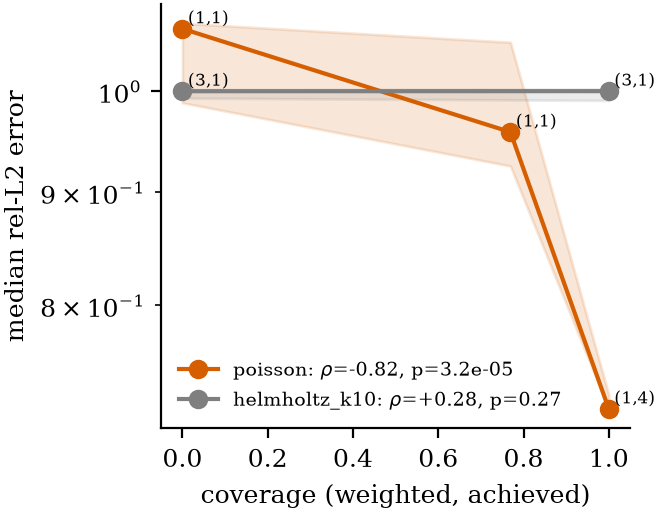

In [2]:
from IPython.display import Image, display

result = make_coverage_vs_error_figure(by_problem)
for problem, stats in result.items():
    print(f"{problem:14s} spearman_rho={stats['spearman_rho']:+.3f}  "
          f"p={stats['spearman_p']:.2e}  n={stats['n_points']}")
display(Image(filename=str(OUT_DIR / "coverage_vs_error.png")))

## The honest headline (`FINDINGS.md`)

At the sample size this run achieved (n=2 seeds, not the pre-registered n=5 -- cut
under the Aug 7 deadline), the quantum-advantage hypothesis SMCD was built to test is
**not supported**: on Poisson, the one problem with a full four-family ablation,
`q_serial` underperforms every classical comparator tested. The two mechanistic
explanations proposed for *why* it should help (NTK-block flattening, C2; spectral-bias
relief, C3) point the wrong direction or hold on only one of two checked instances.

What does hold up: the negative-result mechanism on the smoothing control (C4, mostly),
one genuine per-frequency win (C3, Poisson only), matched-capacity statistical parity
(not advantage) on the two hardest instances (C1, generalized PR-3), and -- most
solidly -- the pre-registered, mechanically-adjudicated measurement protocol itself
(C5): all 12 predictions resolved, no `?` left, and it caught real bugs in its own
supporting tooling along the way.

Full breakdown, 14 numbered findings, the C1-C5 table, the decision table and the
post-submission errata: `FINDINGS.md`. Erratum E4 matters for the figure above: the
sweep trained at a reduced budget, and its 18 Poisson points are 9 distinct
measurements (several coverage targets build the same circuit).